In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Wholesale customers data.csv')
print("Data size:", df.shape)
df.head()

Data size: (440, 8)


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


#Data Preparation

In [7]:
X = df.drop(columns=['Channel', 'Region'])

X_log = np.log1p(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [13]:
df.isnull().sum()

,0
Channel,0
Region,0
Fresh,0
Milk,0
Grocery,0
Frozen,0
Detergents_Paper,0
Delicassen,0
KMeans_Labels,0
HC_Labels,0


#Apply Clustering Algorithms

K-Means

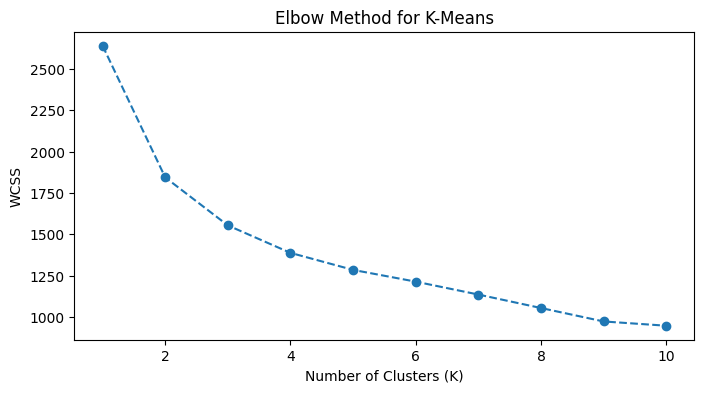

K-Means Silhouette Score: 0.261


In [8]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for K-Means')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

kmeans_model = KMeans(n_clusters=3, init='k-means++', random_state=42)
df['KMeans_Labels'] = kmeans_model.fit_predict(X_scaled)

score_kmeans = silhouette_score(X_scaled, df['KMeans_Labels'])
print(f'K-Means Silhouette Score: {score_kmeans:.3f}')

Hierarchical Clustering

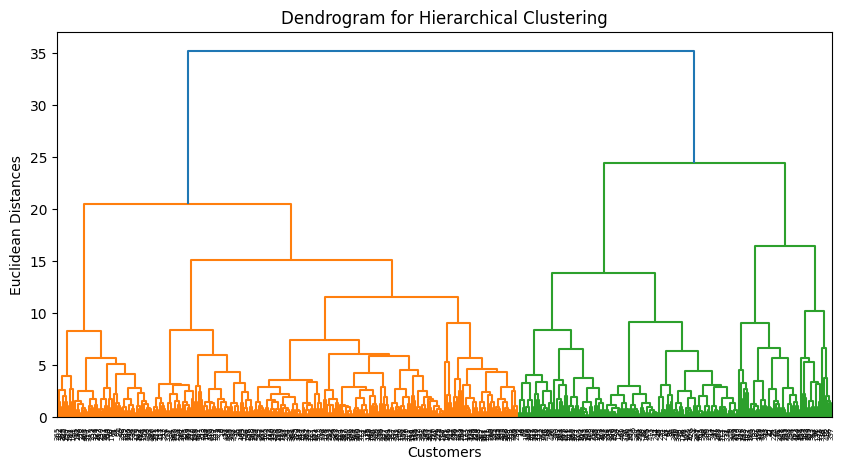

Hierarchical Clustering Silhouette Score: 0.255


In [9]:
plt.figure(figsize=(10, 5))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title('Dendrogram for Hierarchical Clustering')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distances')
plt.show()

hc_model = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
df['HC_Labels'] = hc_model.fit_predict(X_scaled)

score_hc = silhouette_score(X_scaled, df['HC_Labels'])
print(f'Hierarchical Clustering Silhouette Score: {score_hc:.3f}')

DBSCAN

In [19]:
dbscan_model = DBSCAN(eps=1.2, min_samples=5)
df['DBSCAN_Labels'] = dbscan_model.fit_predict(X_scaled)

valid_mask = df['DBSCAN_Labels'] != -1
if len(set(df['DBSCAN_Labels'][valid_mask])) > 1:
    score_dbscan = silhouette_score(X_scaled[valid_mask], df['DBSCAN_Labels'][valid_mask])
    print(f'DBSCAN Silhouette Score (without noise): {score_dbscan:.3f}')
else:
    print('DBSCAN generated only 1 cluster or only noise.')

DBSCAN generated only 1 cluster or only noise.


#Visualization

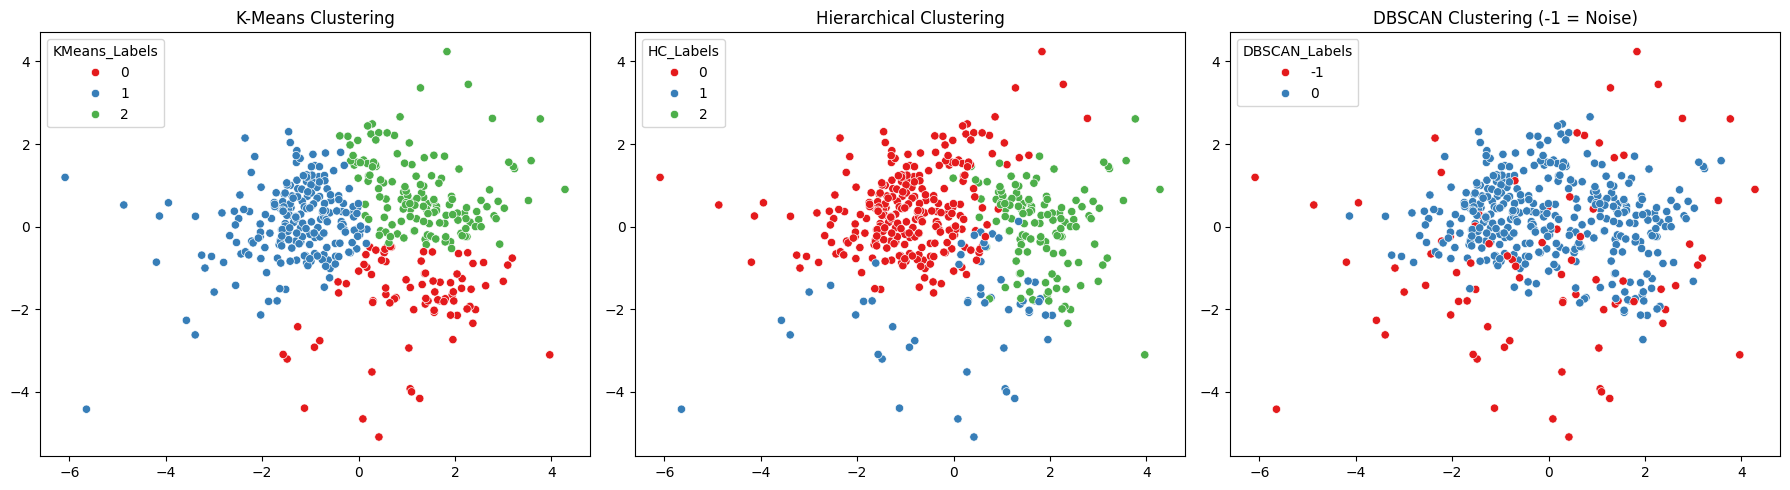

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# K-Means
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['KMeans_Labels'], palette='Set1', ax=axes[0])
axes[0].set_title('K-Means Clustering')

# Hierarchical
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['HC_Labels'], palette='Set1', ax=axes[1])
axes[1].set_title('Hierarchical Clustering')

# DBSCAN
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['DBSCAN_Labels'], palette='Set1', ax=axes[2])
axes[2].set_title('DBSCAN Clustering (-1 = Noise)')

plt.tight_layout()
plt.show()

###  Insights

1. **K-Means Clustering:**
   * **Clear Partitioning:** K-Means successfully separated the data into three well-defined, distinct clusters with minimal overlap.
   * **Balanced Structure:** It created balanced spherical boundaries across the two principal components, showing why it achieved the highest Silhouette Score (**0.2607**).

2. **Hierarchical Clustering:**
   * **High Similarity to K-Means:** The resulting clusters closely resemble K-Means, confirming that a 3-cluster structure is natural for this dataset.
   * **Boundary Differences:** Minor differences appear at the cluster edges (particularly between Cluster 0 and Cluster 2), reflecting the bottom-up tree-based grouping mechanism.

3. **DBSCAN Clustering:**
   * **Noise Sensitivity:** DBSCAN classified most points into a single main cluster (blue dots) while marking sparse, outer points as noise (`-1`, red dots).
   * **Density Limitation:** Because the customer spending data has a relatively continuous density after scaling, DBSCAN struggled to find distinct high-density cores, making it less effective for this specific dataset compared to distance-based models.

In [16]:
from sklearn.metrics import silhouette_score

# 1. Silhouette Score for K-Means
score_kmeans = silhouette_score(X_scaled, df['KMeans_Labels'])

# 2. Silhouette Score for Hierarchical Clustering
score_hc = silhouette_score(X_scaled, df['HC_Labels'])

# 3. Silhouette Score for DBSCAN (Excluding Noise -1)
dbscan_mask = df['DBSCAN_Labels'] != -1

if len(set(df['DBSCAN_Labels'][dbscan_mask])) > 1:
    score_dbscan = silhouette_score(X_scaled[dbscan_mask], df['DBSCAN_Labels'][dbscan_mask])
else:
    score_dbscan = "N/A (Single cluster or all noise)"

# Print Summary Results
print("=" * 40)
print("📊 SILHOUETTE SCORE RESULTS")
print("=" * 40)
print(f"• K-Means Silhouette Score         : {score_kmeans:.4f}")
print(f"• Hierarchical Silhouette Score    : {score_hc:.4f}")
if isinstance(score_dbscan, float):
    print(f"• DBSCAN Silhouette Score (Valid)  : {score_dbscan:.4f}")
else:
    print(f"• DBSCAN Silhouette Score          : {score_dbscan}")
print("=" * 40)

📊 SILHOUETTE SCORE RESULTS
• K-Means Silhouette Score         : 0.2607
• Hierarchical Silhouette Score    : 0.2547
• DBSCAN Silhouette Score          : N/A (Single cluster or all noise)


## 4. Evaluation & Comparison

###  Performance Summary Table

| Criterion | K-Means | Hierarchical Clustering | DBSCAN |
| :--- | :--- | :--- | :--- |
| **Silhouette Score** | **0.2607** | **0.2547** | **N/A** (Single cluster or all noise) |
| **Cluster Shape** | Spherical / Convex | Flexible (Tree-based) | Arbitrary (Density-based) |
| **Number of Clusters** | Fixed ($K=3$) | Fixed ($K=3$) | Automatic |
| **Sensitivity to Noise** | High (Sensitive to outliers) | Moderate (May skew tree) | Low (Isolates noise as `-1`) |

## Critical Thinking

### 1. Which algorithm performed best? Why?
* **Best Performer:** **K-Means** achieved the best performance (Silhouette Score: **0.2607**).
* **Why:**
  * It successfully partitioned the continuous customer spending data into well-separated, spherical clusters.
  * Hierarchical Clustering performed closely (**0.2547**), while DBSCAN struggled due to varying density across features, leading to unassigned noise or single-cluster results.

---

### 2. When would you use each algorithm?
* **K-Means:** When you have a clear idea of the required number of clusters ($K$), clean numerical data, and expect spherical/regular cluster shapes (e.g., general customer segmentation).
* **Hierarchical Clustering:** When you want to explore hierarchical structures, build a taxonomy (e.g., evolutionary trees or nested product categories), and don't know $K$ beforehand.
* **DBSCAN:** When working with spatial/geographical data, arbitrary or complex cluster shapes, and datasets containing a high level of noise and outliers.

---

### 3. What are the strengths and weaknesses of each?

| Algorithm | Strengths | Weaknesses |
| :--- | :--- | :--- |
| **K-Means** | Fast, scalable, easy to implement and interpret. | Sensitive to outliers; requires pre-specifying $K$; assumes spherical clusters. |
| **Hierarchical** | No need to pre-define $K$; produces intuitive visual Dendrograms. | Computationally expensive ($O(n^3)$ time complexity); slow on large datasets. |
| **DBSCAN** | Automatically finds number of clusters; handles complex shapes; robust to noise. | Highly sensitive to hyperparameter tuning (`eps`, `min_samples`); struggles with varying density. |